# Data Preprocessing Pipeline

Notebook này thực hiện toàn bộ quy trình tiền xử lý dữ liệu đánh giá sản phẩm tiếng Việt

**Thứ tự xử lý:**
1. Đọc & làm sạch cơ bản
2. Tiền xử lý văn bản (spam, emoji, teencode…)
3. Dán nhãn cảm xúc từ rating
4. Controlled Downsampling
5. Chia tập Train / Dev / Test
6. Lưu kết quả


##  Import Thư Viện

In [ ]:
!pip install emoji pyvi

import os
import re
import string
import multiprocessing

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import emoji

from pyvi import ViUtils
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from transformers import pipeline
import torch
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")

# Configure matplotlib to use a font that supports Vietnamese characters
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

print("Import thư viện thành công")

Import thư viện thành công


---

## Đọc & Khám Phá Dữ Liệu

> Đọc file dữ liệu thô từ đường dẫn và kiểm tra tổng quan cấu trúc.

In [ ]:
import os
# Đọc dữ liệu
path = '/content/drive/MyDrive/sentiment_analysis_project/data/raw/Product_review_unlabel.xlsx'
df = pd.read_excel(path)

print(" Đọc dữ liệu thành công")

 Đọc dữ liệu thành công


In [ ]:
# Khám phá tổng quan
print(" 1. Kích thước dữ liệu")
print(f"   {df.shape[0]:,} dòng  ×  {df.shape[1]} cột\n")

print(" 2. Số lượng giá trị thiếu mỗi cột")
print(df.isnull().sum().to_string(), "\n")

print(" 3. Số lượng giá trị duy nhất mỗi cột")
print(df.nunique().to_string())

 1. Kích thước dữ liệu
   500,895 dòng  ×  7 cột

 2. Số lượng giá trị thiếu mỗi cột
itemid         0
shopid         0
username    7111
rating         0
time           0
source         0
comment        7 

 3. Số lượng giá trị duy nhất mỗi cột
itemid         918
shopid        1107
username    308321
rating           5
time        438212
source           1
comment     412315


In [ ]:
before = len(df)

# Chuẩn hóa comment trước khi so trùng
df["comment"] = df["comment"].astype(str).str.lower().str.strip()

# Xóa comment trùng (giữ lại dòng đầu tiên)
df = df.drop_duplicates(subset=["comment"], keep="first")

after = len(df)

print(f" Đã xóa {before - after:,} comment trùng")
print(f" Còn lại: {after:,} dòng")

 Đã xóa 90,163 comment trùng
 Còn lại: 410,732 dòng


In [ ]:
print("5 dòng dữ liệu thô mẫu:")
display(df.head(5))

5 dòng dữ liệu thô mẫu:


,itemid,shopid,username,rating,time,source,comment
0,149456305,23469575157,lynguyen030585,5,1692601818,Shopee,chất lượng sản phẩm:tamj ổn\n\ntúi to . đựng c...
1,149456305,23469575157,yumishoploan,5,1695100282,Shopee,"ko có ngon bổ rẻ ,mà chỉ có hợp lý các bác nhé..."
2,149456305,23469575157,5*****7,4,1692351022,Shopee,"chất lượng sản phẩm:sản phẩm giống quảng cáo, ..."
3,149456305,23469575157,grey.nguyen,5,1692684394,Shopee,chất lượng sản phẩm:san pham chat luong tot\n\...
4,607816557,14297501887,t*****6,1,1691942775,Shopee,bấm hết nút và thử đủ hết các chế độ rồi máy c...


---

## Tiền Xử Lý Văn Bản

> Pipeline làm sạch văn bản tiếng Việt theo các bước:
>
> 1. Xóa spam & tag quảng cáo (`[TB]`, `[QC]`, URL, số điện thoại…)
> 2. Chuyển về chữ thường
> 3. Xóa ký tự xuống dòng / tab
> 4. Xóa emoji
> 5. Xóa số
> 6. Xử lý ký tự lặp (`haaaaa` → `ha`)
> 7. Xóa dấu câu
> 8. Chuyển teencode sang từ chuẩn
> 9. Lọc từ rác / vô nghĩa


In [ ]:
import os

# --- Load từ điển ---
def load_dict(path, mode="pair"):
    """Đọc file từ điển dạng tab-separated (key\tvalue)."""
    data = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if mode == "pair" and len(parts) >= 2:
                data[parts[0]] = parts[1].strip()
    return data

dict_base_path = '/content/drive/MyDrive/sentiment_analysis_project/dicts/'

teencode_dict = load_dict(os.path.join(dict_base_path, 'teencode.txt'), mode="pair")


print(f" Đã tải từ điển: {len(teencode_dict):,} teencode ")

 Đã tải từ điển: 359 teencode 


In [ ]:
# --- Định nghĩa các hàm tiền xử lý ---

def remove_spam(text):
    """Xóa toàn bộ nội dung chứa [TB]/[QC] và các nội dung spam (URL, SĐT, từ khóa)."""
    text = str(text)
    if re.search(r"\[(TB|QC)\]", text, flags=re.IGNORECASE):
        return ""
    spam_patterns = [
        r"http\S*", r"www\S*", r"\.com",
        r"mua ngay", r"liên hệ", r"zalo",
        r"fb", r"facebook", r"\d{9,11}"
    ]
    for pattern in spam_patterns:
        if re.search(pattern, text.lower()):
            return ""
    return text.strip()


def to_lowercase(text):
    """Chuyển toàn bộ ký tự về chữ thường."""
    return str(text).lower()


def remove_all_tag(text):
    """Xóa ký tự đặc biệt xuống dòng, tab, carriage return."""
    return re.sub(r'\n|\t|\r', ' ', text)


def remove_emoji(text):
    """Xóa toàn bộ emoji khỏi văn bản."""
    if not isinstance(text, str):
        return ""
    return emoji.replace_emoji(text, replace='')


def remove_numbers(text):
    """Xóa tất cả chữ số."""
    return re.sub(r'\d+', '', text)


def remove_duplicate_letters(text):
    """Rút gọn ký tự lặp liên tiếp (vd: 'haaaa' → 'ha')."""
    return " ".join(
        re.sub(r'(.)\1+', r'\1', w)
        for w in text.split()
    )


def remove_punctuation(text):
    """Thay dấu câu / ký tự đặc biệt bằng khoảng trắng (giữ nguyên chữ tiếng Việt)."""
    return re.sub(r'[^\w\sÀ-ỹ]', ' ', text)


def convert_teencode(text, teencode_dict):
    """Chuyển từ viết tắt / teencode sang từ chuẩn."""
    return " ".join(
        teencode_dict.get(w, w) for w in text.split()
    )

def filter_short_sentence(text, min_words=3):
    """Chỉ giữ câu có số từ > min_words"""
    words = text.split()
    return text if len(words) > min_words else ""

def remove_nonsense_words(text):
    vowels = "aeiouyàáạảãăắằẳẵặâấầẩẫậèéẹẻẽêếềểễệìíịỉĩòóọỏõôốồổỗộơớờởỡợùúụủũưứừửữự"
    clean_words = []

    for w in text.split():
        if len(w) > 25:
            continue

        vowel_count = sum(1 for c in w if c in vowels)
        if vowel_count == 0:
            continue

        if len(w) > 8 and vowel_count / len(w) < 0.15:
            continue

        clean_words.append(w)

    return " ".join(clean_words)


print(" Đã định nghĩa tất cả hàm tiền xử lý")

 Đã định nghĩa tất cả hàm tiền xử lý


In [ ]:
# --- Pipeline tổng hợp ---
def clean_text(text):
    """Áp dụng toàn bộ pipeline tiền xử lý trên một câu."""
    text = remove_spam(text)
    if not text:
        return ""
    text = to_lowercase(text)
    text = remove_all_tag(text)
    text = remove_emoji(text)
    text = remove_numbers(text)
    text = remove_duplicate_letters(text)
    text = remove_punctuation(text)
    text = convert_teencode(text, teencode_dict)
    text = re.sub(r'\s+', ' ', text).strip()   # chuẩn hóa khoảng trắng
    text = remove_nonsense_words(text)
    text = filter_short_sentence(text, min_words=3)
    return text


def clean_dataframe(df, split_name=""):
    """Áp dụng clean_text song song trên cột 'comment', lọc kết quả rỗng."""
    n_jobs = min(6, multiprocessing.cpu_count())
    results = Parallel(n_jobs=n_jobs, backend="loky", batch_size=200, verbose=0)(
        delayed(clean_text)(text) for text in df['comment']
    )

    df = df.copy()
    df['clean_review'] = results

    before = len(df)
    df = df.dropna(subset=['clean_review'])
    df = df[df['clean_review'].str.strip() != ""].copy()
    after = len(df)

    tag = f"[{split_name}] " if split_name else ""
    print(f"  {tag}Loại bỏ {before - after:,} dòng rỗng sau làm sạch → còn {after:,} dòng")
    return df


print(" Pipeline tổng hợp sẵn sàng")

 Pipeline tổng hợp sẵn sàng


In [ ]:
print("  Đang làm sạch văn bản...")
df = clean_dataframe(df)

if "clean_review" not in df.columns:
    df["clean_review"] = df["comment"].apply(lambda x: clean_text(x))

print("\n Tiền xử lý hoàn tất")

  Đang làm sạch văn bản...
  Loại bỏ 18,158 dòng rỗng sau làm sạch → còn 392,574 dòng

 Tiền xử lý hoàn tất


In [ ]:
print("5 dòng dữ liệu mẫu sau khi xử lý:")
display(df[['comment', 'clean_review']].head(5))

5 dòng dữ liệu mẫu sau khi xử lý:


,comment,clean_review
0,chất lượng sản phẩm:tamj ổn\n\ntúi to . đựng c...,chất lượng sản phẩm tạm ổn túi to đựng chăn mă...
2,"chất lượng sản phẩm:sản phẩm giống quảng cáo, ...",chất lượng sản phẩm sản phẩm giống quảng cáo t...
3,chất lượng sản phẩm:san pham chat luong tot\n\...,chất lượng sản phẩm san pham chat luong tốt cử...
4,bấm hết nút và thử đủ hết các chế độ rồi máy c...,bấm hết nút và thử đủ hết các chế độ rồi máy c...
5,tính năng nổi bật:đẹp\nchất lượng sản phẩm:đẹp...,tính năng nổi bật đẹp chất lượng sản phẩm đẹp ...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


---

## Dán Nhãn Dữ Liệu (Data Labeling)

Sử dụng mô hình **`mr4/phobert-base-vi-sentiment-analysis`** để dự đoán nhãn cảm xúc trực tiếp từ văn bản đã làm sạch.

Mô hình trả về 3 nhãn:
- **`Label 0` (Tiêu cực / NEG)**
- **`Label 1` (Trung tính / NEU)**
- **`Label 2` (Tích cực / POS)**




In [ ]:
MODEL_NAME = "mr4/phobert-base-vi-sentiment-analysis"
BATCH_SIZE = 16
MAX_LENGTH = 128

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Thiết bị sử dụng: {device.upper()}")

print(f" Đang tải Tokenizer và Mô hình: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

if device == "cuda":
    model.half()

ID_MAP = [0, 2, 1]

class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = [str(t) if pd.notna(t) else "" for t in texts]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

def collate_fn(batch):
    return tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

def predict_labels_safe(texts, batch_size=BATCH_SIZE):
    dataset = TextDataset(texts)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device == "cuda")
    )

    results = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang dán nhãn"):
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)

            raw_preds = torch.argmax(outputs.logits, dim=-1).cpu().tolist()
            mapped_preds = [ID_MAP[p] for p in raw_preds]
            results.extend(mapped_preds)

    return results

print("\n Bắt đầu dự đoán...")
texts = df["clean_review"].tolist()
df["label"] = predict_labels_safe(texts, batch_size=BATCH_SIZE)

print(f"\n Dán nhãn hoàn tất!")
print(df["label"].value_counts().rename({0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"}).to_string())

 Thiết bị sử dụng: CUDA
 Đang tải Tokenizer và Mô hình: mr4/phobert-base-vi-sentiment-analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/993 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mr4/phobert-base-vi-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Bắt đầu dự đoán...


Đang dán nhãn:   0%|          | 0/24536 [00:00<?, ?it/s]


 Dán nhãn hoàn tất!
label
Tích cực      279390
Trung tính     58806
Tiêu cực       54378


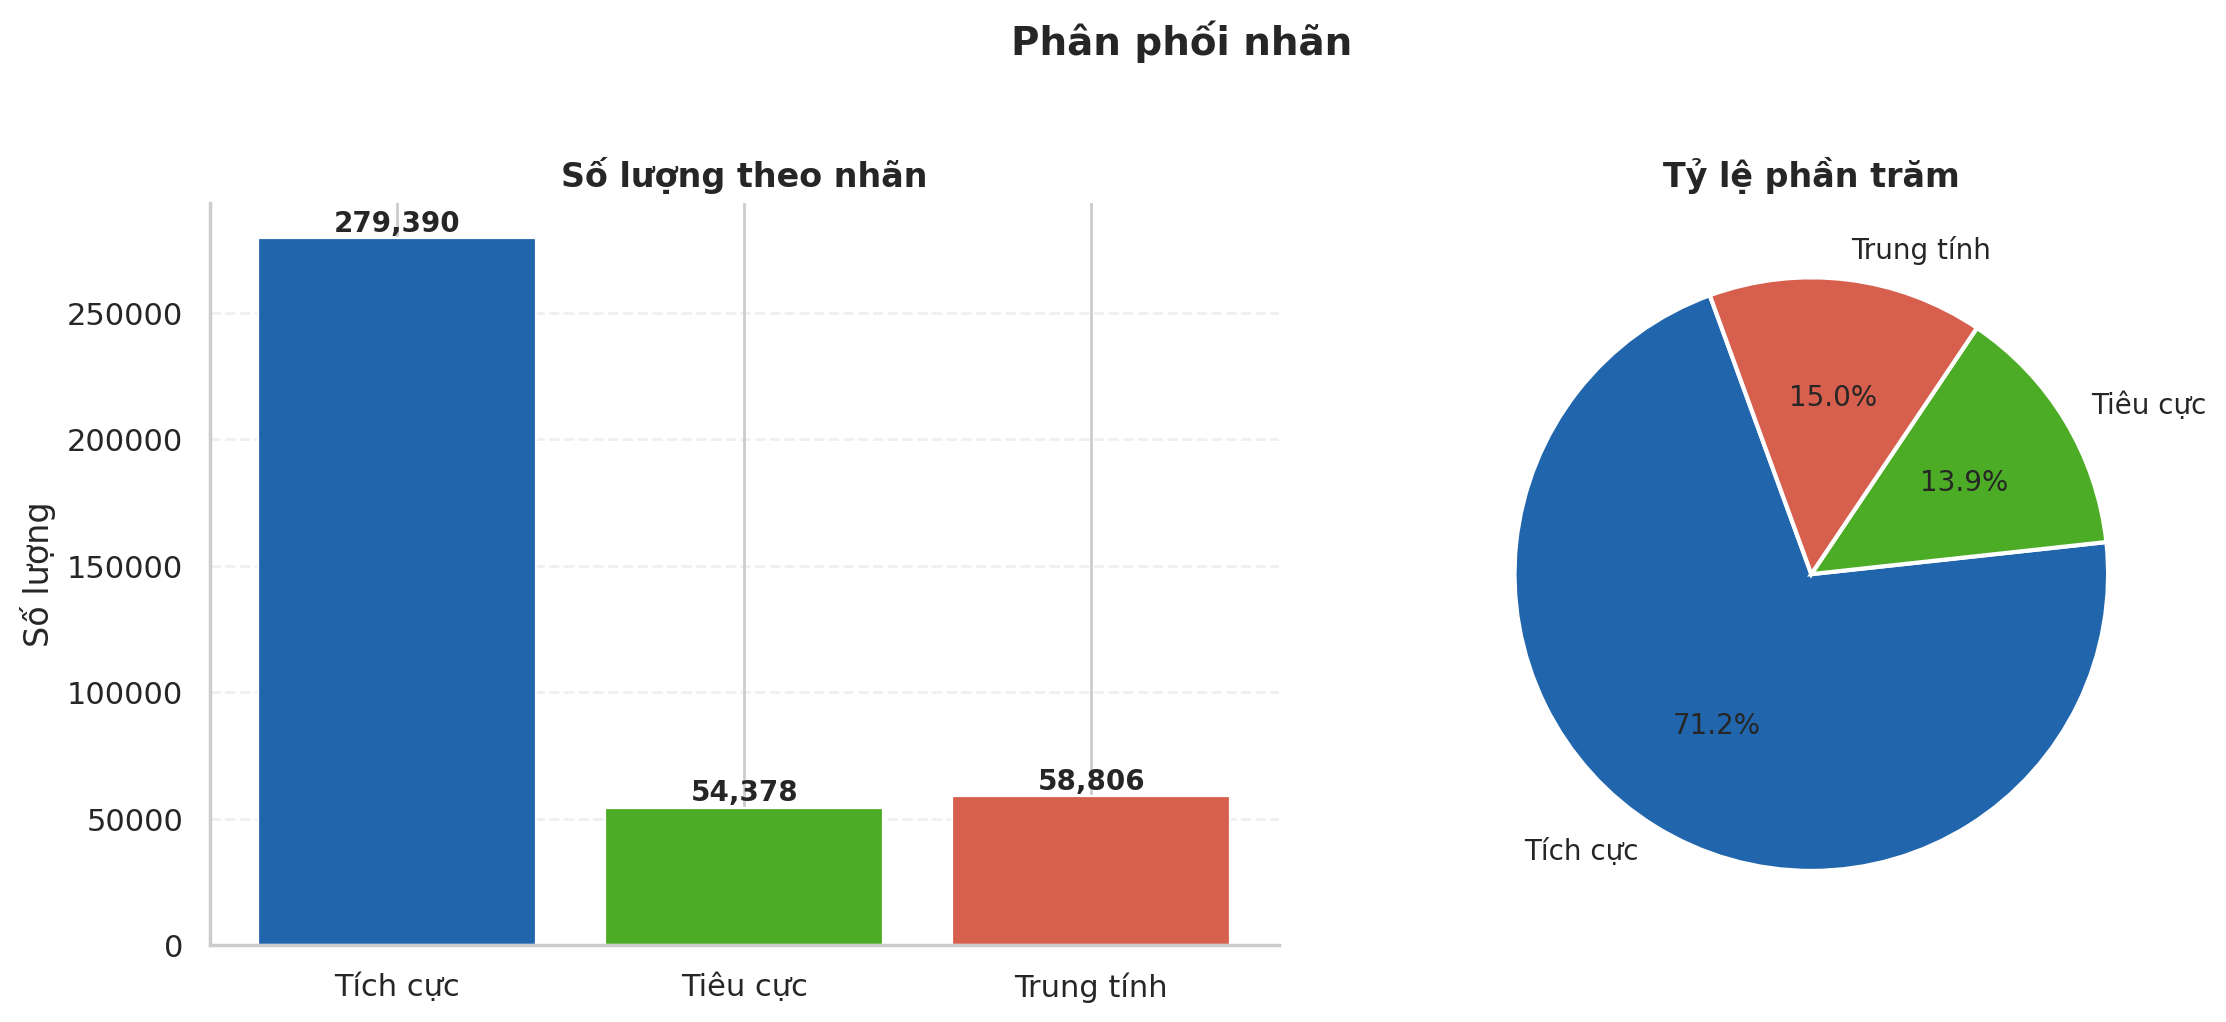

In [ ]:
# --- Visualize phân phối nhãn trước downsampling ---
names = {2: 'Tích cực', 1: 'Trung tính', 0: 'Tiêu cực'}

df_pos_raw = df[df['label'] == 2]
df_neg_raw = df[df['label'] == 0]
df_neu_raw = df[df['label'] == 1]

data_viz = pd.DataFrame({
    "Nhóm":    ["Tích cực", "Tiêu cực", "Trung tính"],
    "Số lượng": [len(df_pos_raw), len(df_neg_raw), len(df_neu_raw)]
})

# Bảng màu
bar_colors = ['#2166AC', '#4DAC26', '#D6604D']   # xanh dương, xanh lá, đỏ cam
pie_colors = ['#2166AC', '#4DAC26', '#D6604D']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Phân phối nhãn", fontsize=14, fontweight='bold', y=1.02)

# Bar chart
bars = ax[0].bar(data_viz["Nhóm"], data_viz["Số lượng"],
                 color=bar_colors, edgecolor='white', linewidth=0.8)
ax[0].set_title("Số lượng theo nhãn", fontweight='bold')
ax[0].set_ylabel("Số lượng")
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].grid(axis='y', alpha=0.3, linestyle='--')
ax[0].set_axisbelow(True)
for i, v in enumerate(data_viz["Số lượng"]):
    ax[0].text(i, v + max(data_viz["Số lượng"]) * 0.01, f"{v:,}",
               ha='center', fontweight='bold', fontsize=10)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
ax[1].pie(data_viz["Số lượng"], labels=data_viz["Nhóm"],
          autopct='%1.1f%%', startangle=110,
          colors=pie_colors, wedgeprops=wedge_props,
          textprops={'fontsize': 10})
ax[1].set_title("Tỷ lệ phần trăm", fontweight='bold')

plt.tight_layout()
plt.show()

---

## Controlled Downsampling

> Dữ liệu bị mất cân bằng nghiêm trọng (phần lớn là **Tích cực**).
> Áp dụng **Controlled Downsampling** để đạt tỷ lệ phân phối mục tiêu:
>
> | Nhãn | Tỷ lệ mục tiêu |
> |------|----------------|
> | Trung tính | ~25% |
> | Tiêu cực | ~35% |
> | Tích cực | ~40% |


In [ ]:
counts = df['label'].value_counts().to_dict()

# Desired total number of samples
total_desired_samples = 60000

desired_relative_props = {
    2: 40,
    0: 35,
    1: 25
}

target = {}
for label, prop in desired_relative_props.items():
    target_count = int(total_desired_samples * (prop / 100))
    target[label] = min(target_count, counts[label])

total_actual_sampled = sum(target.values())

print(" Target số lượng sau downsampling:")
for k, v in target.items():
    print(f"   {names[k]:<12}: {v:,}  ({v/total_actual_sampled*100:.1f}%)")

sampled_parts = [
    df[df['label'] == label].sample(n=n, random_state=42)
    for label, n in target.items()
]

df_balanced = (
    pd.concat(sampled_parts)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(f"\n Phân phối sau downsampling ({len(df_balanced):,} mẫu):")
vc = df_balanced['label'].value_counts()
for k, v in vc.items():
    print(f"   {names[k]:<12}: {v:,}  ({v/len(df_balanced)*100:.1f}%)")

print(f"\n Tổng số mẫu mục tiêu (trước sampling): {sum(target.values()):,}")

 Target số lượng sau downsampling:
   Tích cực    : 24,000  (40.0%)
   Tiêu cực    : 21,000  (35.0%)
   Trung tính  : 15,000  (25.0%)

 Phân phối sau downsampling (60,000 mẫu):
   Tích cực    : 24,000  (40.0%)
   Tiêu cực    : 21,000  (35.0%)
   Trung tính  : 15,000  (25.0%)

 Tổng số mẫu mục tiêu (trước sampling): 60,000


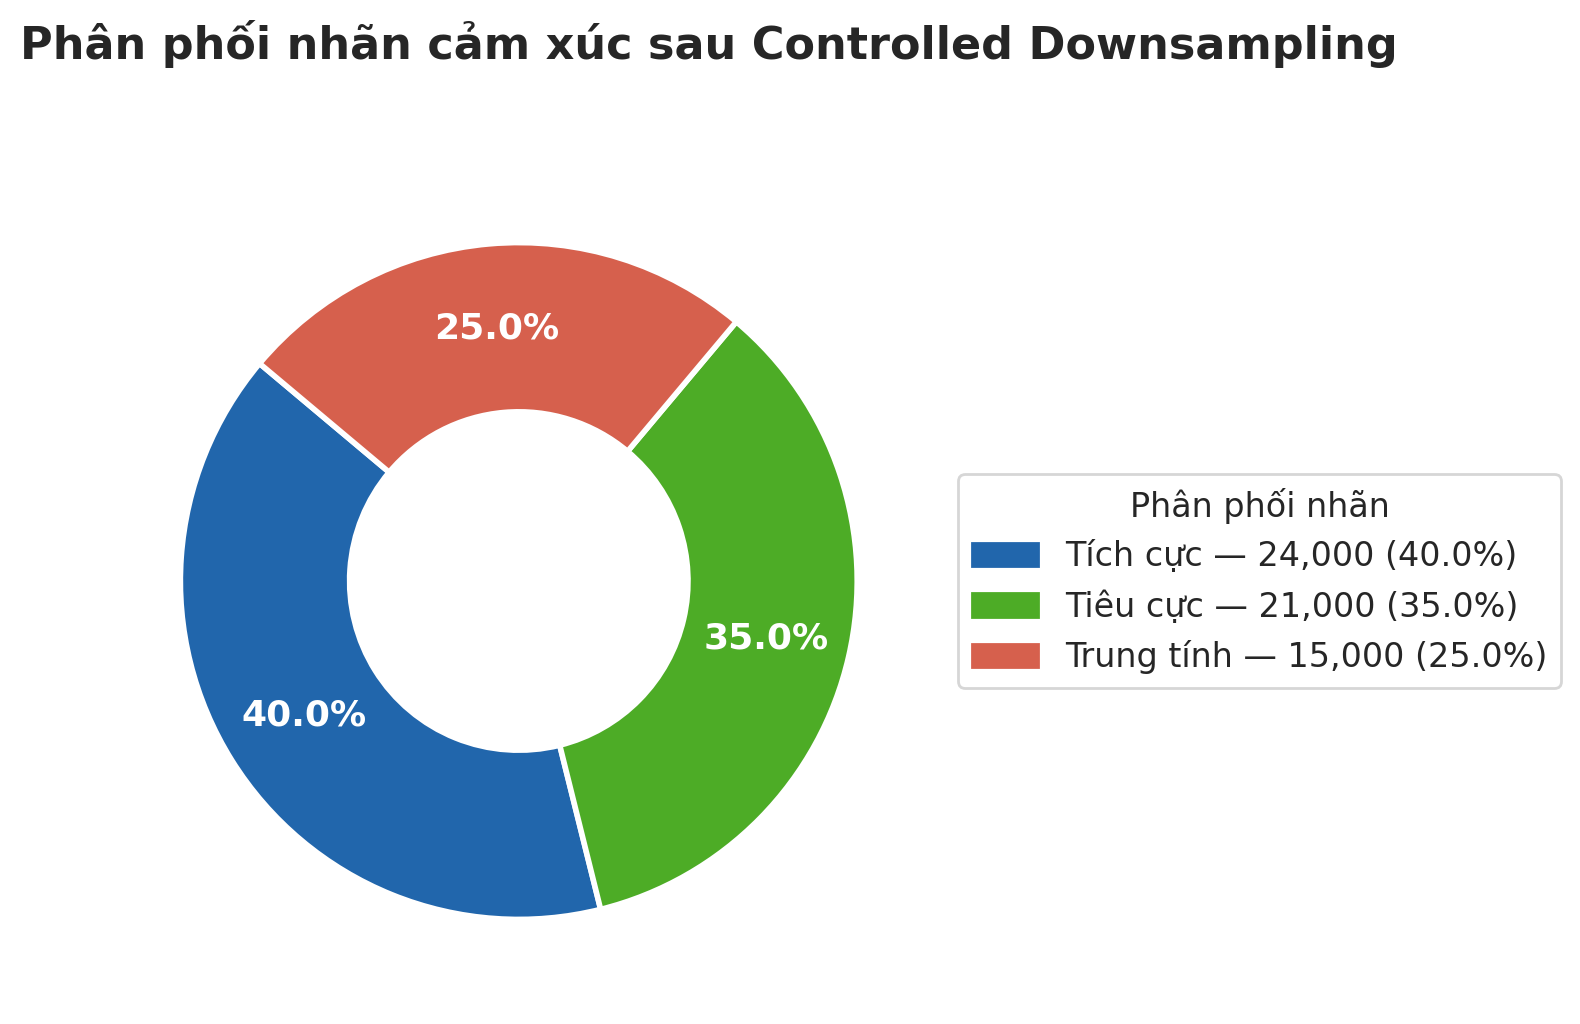

In [ ]:
# Visualize phân phối sau downsampling ---
vc = df_balanced['label'].value_counts()
labels_list = [names[k] for k in vc.index]
sizes       = vc.values

# Bảng màu
colors = ['#2166AC', '#4DAC26', '#D6604D']

plt.rc('font', size=12)

fig, ax = plt.subplots(figsize=(8, 5))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [
    f'{l} — {s:,} ({s/sum(sizes)*100:.1f}%)'
    for l, s in zip(labels_list, sizes)
]
patches = [mpatches.Patch(color=c, label=lb) for c, lb in zip(colors, legend_labels)]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=12, frameon=True, title='Phân phối nhãn')

fig.suptitle('Phân phối nhãn cảm xúc sau Controlled Downsampling',
             fontsize=16, fontweight='bold', x=0.45, y=1.02)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

---

## Chia Tập Train / Dev / Test

> Chia tập dữ liệu đã cân bằng & đã tiền xử lý theo tỷ lệ **70 / 15 / 15** (stratified theo nhãn).


### Phân phối độ dài bình luận

In [ ]:
# --- Chia tập ---
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30, stratify=df_balanced['label'], random_state=42
)
dev_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

total = len(df_balanced)
print(" Kết quả chia tập (trước tiền xử lý):")
print(f"   Train : {len(train_df):>6,}  ({len(train_df)/total*100:.1f}%)")
print(f"   Dev   : {len(dev_df):>6,}  ({len(dev_df)/total*100:.1f}%)")
print(f"   Test  : {len(test_df):>6,}  ({len(test_df)/total*100:.1f}%)")
print(f"   Tổng  : {total:>6,}")

 Kết quả chia tập (trước tiền xử lý):
   Train : 42,000  (70.0%)
   Dev   :  9,000  (15.0%)
   Test  :  9,000  (15.0%)
   Tổng  : 60,000


In [ ]:
# --- Kiểm tra: văn bản đã sạch sẵn, không cần xử lý thêm ---
print(" Văn bản đã được tiền xử lý trước khi chia tập.")
print(f"   Train : {len(train_df):,}  |  Dev : {len(dev_df):,}  |  Test : {len(test_df):,}")


 Văn bản đã được tiền xử lý trước khi chia tập.
   Train : 42,000  |  Dev : 9,000  |  Test : 9,000


In [ ]:
# --- Kiểm tra mẫu ---
print(" Mẫu tập Train:")
display(train_df[['comment', 'clean_review', 'label']].head(5))

print("\n Mẫu tập Dev:")
display(dev_df[['comment', 'clean_review', 'label']].head(3))

print("\n Mẫu tập Test:")
display(test_df[['comment', 'clean_review', 'label']].head(3))

 Mẫu tập Train:


,comment,clean_review,label
57784,chất liệu:vải\nđúng với mô tả:đúng\nmàu sắc:đe...,chất liệu vải đúng với mô tả đúng màu sắc đen ...,2
3243,k thấy thơm gì cả mùi còn kiểu gì ấy,không thấy thơm gì cả mùi còn kiểu gì ấy,0
23301,"chất liệu:mềm, thoáng mát\nđúng với mô tả:đúng...",chất liệu mềm thoáng mát đúng với mô tả đúng m...,2
16578,vừa đặt cái hôm sau tới tay liền nhưng nó nhỏ ...,vừa đặt cái hôm sau tới tay liền nhưng nó nhỏ ...,1
49969,chất liệu:oke\n\nmình đặt nhầm thành size 32 n...,chất liệu ok mình đặt nhầm thành cỡ nhưng cửa ...,2



 Mẫu tập Dev:


,comment,clean_review,label
9114,màu sắc:giống\nchất liệu:cũng được\nđúng với m...,màu sắc giống chất liệu cũng được đúng với mô ...,0
18341,giao hai bộ cung mau that thất vong,giao hai bộ cung mau that thất vong,0
29256,đúng với mô tả:đúng\nchất liệu:jean\nmàu sắc:x...,đúng với mô tả đúng chất liệu jean màu sắc xám...,2



 Mẫu tập Test:


,comment,clean_review,label
47551,tengen là một thanh niên có vẻ ngoài cao lớn v...,tengen là một thanh niên có vẻ ngoài cao lớn v...,2
46470,"sản phẩm ổn, nhưng mua đợt này k dùng bluetoot...",sản phẩm ổn nhưng mua đợt này không dùng bluet...,1
44667,màu sắc:giao đúng\nđúng với mô tả:mặc dù để si...,màu sắc giao đúng đúng với mô tả mặc dù để cỡ ...,2


In [ ]:
# --- Thống kê phân phối nhãn từng tập ---
def print_label_dist(df, split_name):
    vc = df["label"].value_counts().sort_index()
    print(f"{split_name} ({len(df):,} mẫu):")
    for k, v in vc.items():
        print(f"   {names[k]:<12}: {v:>5,}  ({v/len(df)*100:.1f}%)")
    print()

print_label_dist(train_df, "Train")
print_label_dist(dev_df,   "Dev")
print_label_dist(test_df,  "Test")

Train (42,000 mẫu):
   Tiêu cực    : 14,700  (35.0%)
   Trung tính  : 10,500  (25.0%)
   Tích cực    : 16,800  (40.0%)

Dev (9,000 mẫu):
   Tiêu cực    : 3,150  (35.0%)
   Trung tính  : 2,250  (25.0%)
   Tích cực    : 3,600  (40.0%)

Test (9,000 mẫu):
   Tiêu cực    : 3,150  (35.0%)
   Trung tính  : 2,250  (25.0%)
   Tích cực    : 3,600  (40.0%)



---

##  Lưu Kết Quả

> Xuất 3 tập dữ liệu đã xử lý sang thư mục `data/processed/`.


In [ ]:
output_dir = '/content/drive/MyDrive/sentiment_analysis_project/data/processed/'
os.makedirs(output_dir, exist_ok=True)

train_df.to_excel(os.path.join(output_dir, 'train.xlsx'), index=False)
dev_df.to_excel(os.path.join(output_dir, 'dev.xlsx'),   index=False)
test_df.to_excel(os.path.join(output_dir, 'test.xlsx'), index=False)

print("Đã lưu 3 tập dữ liệu vào:", output_dir)

n_train = len(train_df)
n_dev   = len(dev_df)
n_test  = len(test_df)
total   = n_train + n_dev + n_test

print(f"\n Tóm tắt kết quả cuối cùng:")
print(f"   Train : {n_train:,}")
print(f"   Dev   : {n_dev:,}")
print(f"   Test  : {n_test:,}")
print(f"   {'─'*20}")
print(f"   Tổng  : {total:,}")

Đã lưu 3 tập dữ liệu vào: /content/drive/MyDrive/sentiment_analysis_project/data/processed/

 Tóm tắt kết quả cuối cùng:
   Train : 42,000
   Dev   : 9,000
   Test  : 9,000
   ────────────────────
   Tổng  : 60,000


## Hướng dẫn Mount Google Drive

Để truy cập các tệp tin trong Google Drive của bạn từ Colab, bạn cần "mount" Drive. Điều này cho phép Colab coi Drive của bạn như một hệ thống tệp cục bộ. Bạn có thể làm điều này bằng cách sử dụng đoạn mã sau:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Khi bạn chạy đoạn mã trên, một cửa sổ xác thực sẽ xuất hiện. Bạn cần làm theo các bước sau:

1.  Nhấp vào liên kết được cung cấp để ủy quyền tài khoản Google của bạn.
2.  Chọn tài khoản Google mà bạn muốn sử dụng.
3.  Nhấp vào "Allow" (Cho phép) để cấp quyền cho Google Colab truy cập Google Drive của bạn.
4.  Sao chép mã xác thực được cung cấp và dán vào ô nhập liệu trong Colab, sau đó nhấn Enter.

Sau khi hoàn tất, bạn sẽ thấy thông báo `Mounted at /content/drive`, cho biết Google Drive của bạn đã được mount thành công. Bây giờ bạn có thể truy cập các tệp tin của mình tại đường dẫn `/content/drive/MyDrive/`.